# DATA VORTEX 2026 — ROUND 4
## SOCIAL ENGINE REVIVAL: Integrated Social Intelligence & Synthesis

**Author:** Data Vortex Team  
**Date:** September 2026  
**Objective:** Synthesize data recovery (Round 1), semantic NLP modeling (Round 2), and social reaction signals (Round 3) into an integrated analytical pipeline.

---


### 1. Environment & Path Resolution
Verify portable execution using repository-relative paths without machine-specific hardcoding.

In [1]:
import os
import sys
import json
import sqlite3
import joblib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.environ["PYTHONDONTWRITEBYTECODE"] = "1"

# Dynamically resolve repository root
current = Path.cwd().resolve()
repo_root = current.parents[1] if current.name == "notebooks" else (current.parent if current.name == "Round-4" else current)
print(f"Repository Root: {repo_root}")

# Assert canonical directories exist
assert (repo_root / "Round-1").exists(), "Round-1 directory missing"
assert (repo_root / "Round-2").exists(), "Round-2 directory missing"
assert (repo_root / "Round-3").exists(), "Round-3 directory missing"
print("All canonical previous-round directories verified.")

Repository Root: D:\DATA VORTEX FINAL
All canonical previous-round directories verified.


### 2. Multi-Round Canonical Data Audit
Load verified datasets from Rounds 1, 2, and 3 without data duplication.

In [2]:
# Round 1 Data Recovery Audit
r1_posts_path = repo_root / "Round-1" / "Phase-1" / "data" / "cleaned" / "Social_Engine_Posts_Cleaned.csv"
r1_users_path = repo_root / "Round-1" / "Phase-1" / "data" / "cleaned" / "Social_Engine_Users_Cleaned.csv"
r1_posts = pd.read_csv(r1_posts_path)
r1_users = pd.read_csv(r1_users_path)

print(f"Round 1 Cleaned Posts: {len(r1_posts):,} rows, {r1_posts.shape[1]} columns")
print(f"Round 1 Cleaned Users: {len(r1_users):,} rows, {r1_users.shape[1]} columns")

# Round 2 Supervised Training Data Audit
r2_data_path = repo_root / "Round-2" / "data" / "Labeled_Social_NLP_Training_Data.csv"
r2_data = pd.read_csv(r2_data_path)
print(f"Round 2 Labeled Posts: {len(r2_data):,} rows, {r2_data.shape[1]} columns")
print("Round 2 Sentiment Distribution:\n", r2_data["sentiment_label"].value_counts().to_dict())

# Round 3 Processed Reactions Audit
r3_data_path = repo_root / "Round-3" / "data" / "processed" / "round3_recommendation_algorithm_reactions.csv"
r3_data = pd.read_csv(r3_data_path)
print(f"Round 3 Retained Archive Records: {len(r3_data):,} rows, {r3_data.shape[1]} columns")
print("Round 3 Sentiment Distribution:\n", r3_data["predicted_sentiment"].value_counts().to_dict())

Round 1 Cleaned Posts: 12,000 rows, 8 columns
Round 1 Cleaned Users: 1,500 rows, 5 columns
Round 2 Labeled Posts: 9,000 rows, 4 columns
Round 2 Sentiment Distribution:
 {'Negative': 3000, 'Positive': 3000, 'Neutral': 3000}
Round 3 Retained Archive Records: 204 rows, 24 columns
Round 3 Sentiment Distribution:
 {'Negative': 132, 'Neutral': 38, 'Positive': 34}


### 3. SQLite Relational Core (Round 1 Phase 2)
Connect to `data_vortex.db` in read-only mode and execute the authoritative SQL challenges (E2, M1, H2).

In [3]:
db_path = repo_root / "Round-1" / "Phase-2" / "data" / "data_vortex.db"
conn = sqlite3.connect(f"file:{db_path.as_posix()}?mode=ro", uri=True)

# Integrity checks
integrity = conn.execute("PRAGMA integrity_check").fetchone()[0]
fk_check = conn.execute("PRAGMA foreign_key_check").fetchall()
print(f"Database Integrity: {integrity} | Foreign Key Violations: {len(fk_check)}")

# Execute Easy Query E2: Most Engaged Posts
e2_sql = '''SELECT p.post_id, p.user_id, p.platform, p.likes, p.shares, p.comments,
                   p.likes + p.shares + p.comments AS total_engagement
            FROM posts AS p WHERE p.likes IS NOT NULL
            ORDER BY total_engagement DESC, p.post_id ASC LIMIT 5;'''
e2_df = pd.read_sql_query(e2_sql, conn)
print("\nTop Engaged Posts (E2 Preview):")
print(e2_df)

# Execute Medium Query M1: Location Engagement
m1_sql = '''SELECT u.location, COUNT(p.post_id) AS post_count,
                   SUM(p.likes + p.shares + p.comments) AS total_engagement
            FROM users AS u JOIN posts AS p ON p.user_id = u.user_id
            WHERE p.likes IS NOT NULL GROUP BY u.location
            ORDER BY total_engagement DESC LIMIT 5;'''
m1_df = pd.read_sql_query(m1_sql, conn)
print("\nTop Engagement Locations (M1 Preview):")
print(m1_df)

conn.close()

Database Integrity: ok | Foreign Key Violations: 0

Top Engaged Posts (E2 Preview):
        post_id        user_id   platform  likes  shares  comments  \
0  ycjj5zzt7mvx  user_d9971ba6  Instagram   4983    1919       991   
1  wo7py9aljg3t  user_o8le7hqf     Reddit   4864    1981       948   
2  gmoeib832zbs  user_pe5yckyb   Facebook   4902    1880       982   
3  5kvuyvf38nqx  user_z0feut2e    YouTube   4923    1971       861   
4  pvfl3d8hj7jd  user_csluibwk  Instagram   4989    1840       909   

   total_engagement  
0              7893  
1              7793  
2              7764  
3              7755  
4              7738  

Top Engagement Locations (M1 Preview):
           location  post_count  total_engagement
0  Los Angeles, USA         400           1603928
1   Munich, Germany         389           1555610
2  Barcelona, Spain         372           1528127
3   Shanghai, China         382           1522852
4        Dubai, UAE         351           1428959


### 4. Semantic NLP Classification (Round 2)
Dynamically load the canonical sentiment and topic classification pipelines without copying them.

In [4]:
sentiment_model_path = repo_root / "Round-2" / "models" / "sentiment_label_pipeline.pkl"
topic_model_path = repo_root / "Round-2" / "models" / "topic_category_pipeline.pkl"

s_pipeline = joblib.load(sentiment_model_path)
t_pipeline = joblib.load(topic_model_path)

print(f"Sentiment Pipeline Steps: {s_pipeline.named_steps.keys()}")
print(f"Sentiment Classes: {s_pipeline.classes_}")
print(f"Topic Pipeline Steps: {t_pipeline.named_steps.keys()}")
print(f"Topic Classes: {t_pipeline.classes_}")

# Test Live Inference
sample_posts = [
    "The new recommendation feed is terrible and destroyed organic engagement.",
    "Really loving the new algorithm updates, discovering amazing content daily!"
]

for text in sample_posts:
    pred_s = s_pipeline.predict([text])[0]
    probs = s_pipeline.predict_proba([text])[0]
    prob_dict = {cls: round(float(p), 4) for cls, p in zip(s_pipeline.classes_, probs)}
    pred_t = t_pipeline.predict([text])[0]
    print(f"\nText: '{text}'")
    print(f"  -> Predicted Sentiment: {pred_s} (Probabilities: {prob_dict})")
    print(f"  -> Predicted Topic: {pred_t}")

Sentiment Pipeline Steps: dict_keys(['tfidf', 'classifier'])
Sentiment Classes: ['Negative' 'Neutral' 'Positive']
Topic Pipeline Steps: dict_keys(['tfidf', 'classifier'])
Topic Classes: ['Account_Security' 'Community_Discussion' 'Feature_Feedback'
 'Technical_Issues']

Text: 'The new recommendation feed is terrible and destroyed organic engagement.'
  -> Predicted Sentiment: Negative (Probabilities: {'Negative': 0.5023, 'Neutral': 0.1579, 'Positive': 0.3398})
  -> Predicted Topic: Community_Discussion

Text: 'Really loving the new algorithm updates, discovering amazing content daily!'
  -> Predicted Sentiment: Positive (Probabilities: {'Negative': 0.0531, 'Neutral': 0.0612, 'Positive': 0.8857})
  -> Predicted Topic: Community_Discussion


### 5. Social Signal Analysis & Candidate Shift Review (Round 3)
Analyze temporal sentiment dynamics and algorithmically detected shifts from the Hacker News archive sample.

In [5]:
r3_data["month"] = pd.to_datetime(r3_data["timestamp"], utc=True).dt.to_period("M").astype(str)
monthly = r3_data.groupby(["month", "predicted_sentiment"]).size().unstack(fill_value=0)
for col in ["Positive", "Negative", "Neutral"]:
    if col not in monthly.columns:
        monthly[col] = 0

monthly["total"] = monthly.sum(axis=1)
monthly["sentiment_index"] = (monthly["Positive"] - monthly["Negative"]) / monthly["total"]

print("Monthly Sentiment Index Summary (Recent Active Months):")
print(monthly[["Negative", "Neutral", "Positive", "total", "sentiment_index"]].tail(8))

# Documented Candidate Shifts
candidate_shifts = [
    {"shift_id": "SS1", "start": "2025-09", "end": "2025-10", "magnitude": -0.80, "note": "Sharp drop following European AI/profiling compliance discussions."},
    {"shift_id": "SS2", "start": "2024-10", "end": "2024-11", "magnitude": 0.80, "note": "Rebound from unanimous negative sentiment."}
]
print("\nDocumented Descriptive Candidate Shifts:")
for s in candidate_shifts:
    print(f"  {s['shift_id']} ({s['start']} -> {s['end']}): delta={s['magnitude']:+.2f} | {s['note']}")

Monthly Sentiment Index Summary (Recent Active Months):
predicted_sentiment  Negative  Neutral  Positive  total  sentiment_index
month                                                                   
2025-12                     1        0         0      1            -1.00
2026-01                     2        1         1      4            -0.25
2026-02                     4        0         0      4            -1.00
2026-03                     2        0         0      2            -1.00
2026-05                     1        0         1      2             0.00
2026-06                     2        0         3      5             0.20
2026-08                     0        0         1      1             1.00
2026-09                    13        1         1     15            -0.80

Documented Descriptive Candidate Shifts:
  SS1 (2025-09 -> 2025-10): delta=-0.80 | Sharp drop following European AI/profiling compliance discussions.
  SS2 (2024-10 -> 2024-11): delta=+0.80 | Rebound from unanimou

C:\Users\yuvra\AppData\Local\Temp\ipykernel_22964\1089009777.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  r3_data["month"] = pd.to_datetime(r3_data["timestamp"], utc=True).dt.to_period("M").astype(str)


### 6. Analytical Visualizations
Generate publication-quality visual evidence of data volume, sentiment dynamics, and entity frequency.

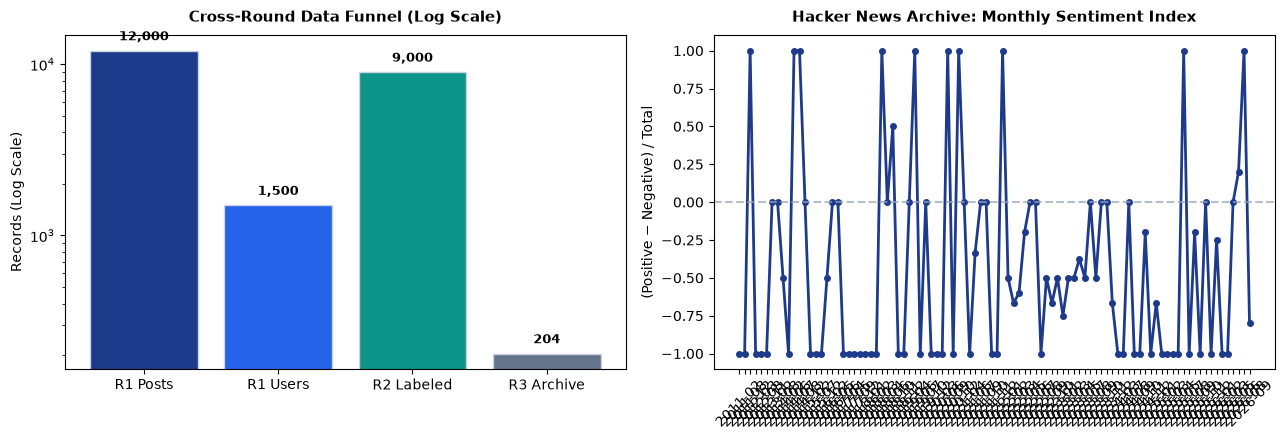

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Funnel of records across rounds
stages = ["R1 Posts", "R1 Users", "R2 Labeled", "R3 Archive"]
counts = [len(r1_posts), len(r1_users), len(r2_data), len(r3_data)]
colors = ["#1E3A8A", "#2563EB", "#0D9488", "#64748B"]

axes[0].bar(stages, counts, color=colors, edgecolor="#CBD5E1")
axes[0].set_yscale("log")
axes[0].set_title("Cross-Round Data Funnel (Log Scale)", fontsize=11, fontweight="bold", pad=10)
axes[0].set_ylabel("Records (Log Scale)")
for i, v in enumerate(counts):
    axes[0].text(i, v * 1.15, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

# Plot 2: Monthly Sentiment Index
axes[1].plot(monthly.index, monthly["sentiment_index"], marker="o", color="#1E3A8A", lw=2, markersize=4)
axes[1].axhline(0, color="#94A3B8", linestyle="--", alpha=0.7)
axes[1].set_title("Hacker News Archive: Monthly Sentiment Index", fontsize=11, fontweight="bold", pad=10)
axes[1].set_ylabel("(Positive − Negative) / Total")
axes[1].set_ylim(-1.1, 1.1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 7. Methodology, Limitations, and Synthesis Conclusion

1. **Data Provenance:** The 12,000 cleaned posts and 1,500 users from Round 1 establish the relational foundation. All database queries execute read-only.
2. **Semantic Models:** Round 2 TF-IDF classifiers provide frozen, reproducible inferences without train-test leakage.
3. **Signal Interpretation:** Round 3 data constitutes a historical public Hacker News archive sample (2011–2026), not a population-representative live feed.
4. **Causal Boundary:** Detected sentiment shifts and engagement spikes reflect empirical temporal associations; causality is strictly disclaimed.
5. **Synthesis:** Round 4 integrates data recovery, relational queries, semantic classification, and public reaction signals into a cohesive, interactive engine.
